Plot successfully generated and saved as congested_69bus.svg


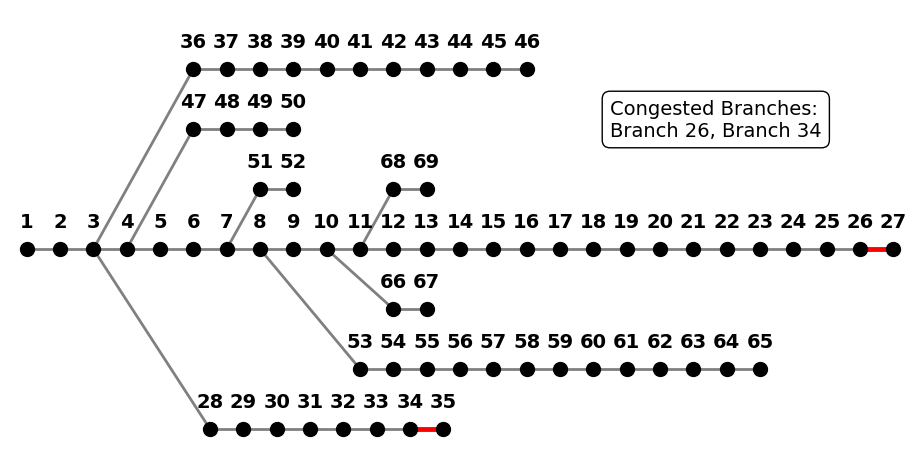

In [71]:
import matplotlib.pyplot as plt
import networkx as nx

# 1. Initialize the Graph
G = nx.Graph()

# 2. Define ALL edges in the IEEE 69-bus system
main_feeder = [(i, i+1) for i in range(1, 27)] # Buses 1 to 27
lateral_1 = [(3, 28), (28, 29), (29, 30), (30, 31), (31, 32), (32, 33), (33, 34), (34, 35)]
lateral_2 = [(3, 36), (36, 37), (37, 38), (38, 39), (39, 40), (40, 41), (41, 42), (42, 43), (43, 44), (44, 45), (45, 46)]
lateral_3 = [(4, 47), (47, 48), (48, 49), (49, 50)]
lateral_4 = [(7, 51), (51, 52)]
lateral_5 = [(8, 53), (53, 54), (54, 55), (55, 56), (56, 57), (57, 58), (58, 59), (59, 60), (60, 61), (61, 62), (62, 63), (63, 64), (64, 65)]
lateral_6 = [(10, 66), (66, 67)]
lateral_7 = [(11, 68), (68, 69)]

all_edges = main_feeder + lateral_1 + lateral_2 + lateral_3 + lateral_4 + lateral_5 + lateral_6 + lateral_7
G.add_edges_from(all_edges)

# 3. Manually map physical (x, y) coordinates (Aggressively compacted)
pos = {}

# Main feeder (Buses 1 to 27) in a straight horizontal line
for i in range(1, 28): pos[i] = (i-0.5, 0)

# Laterals mapped to extremely tight vertical coordinates
for i in range(28, 36): pos[i] = (i - 22, -1.2)  # Lateral 1 (Bottom)
for i in range(36, 47): pos[i] = (i - 30.5, 1.2)   # Lateral 2 (Top highest)
for i in range(47, 51): pos[i] = (i - 41.5, 0.8)   # Lateral 3 (Top middle)
for i in range(51, 53): pos[i] = (i - 43.5, 0.4)   # Lateral 4 (Top lower)
for i in range(53, 66): pos[i] = (i - 42.5, -0.8)  # Lateral 5 (Bottom middle)
for i in range(66, 68): pos[i] = (i - 54.5, -0.4)  # Lateral 6 (Bottom high)
for i in range(68, 70): pos[i] = (i - 56.5, 0.4)   # Lateral 7 (Top lower right)

# 4. Identify Congested Branches
congested_branches = [(26, 27), (34, 35)]
# Ensure undirected graph edge matching works both ways
congested_set = set(congested_branches + [(v, u) for u, v in congested_branches])

normal_edges = [edge for edge in G.edges() if edge not in congested_set]
highlighted_edges = [edge for edge in G.edges() if edge in congested_set]

# 5. Build the Plot (Tight figsize: 12x4.5 forces everything closer)
plt.figure(figsize=(9, 4.5))

# Draw Grey Branches (Base Network)
nx.draw_networkx_edges(G, pos, edgelist=normal_edges, edge_color='gray', width=2)

# Draw Red Branches (Congestion)
nx.draw_networkx_edges(G, pos, edgelist=highlighted_edges, edge_color='red', width=3.5)

# Draw Black Nodes
nx.draw_networkx_nodes(G, pos, node_color='black', node_size=100)

# Offset Node Labels (Tighter Y offset of 0.18, maintaining large font)
labels_pos = {k: (v[0], v[1] + 0.18) for k, v in pos.items()}
nx.draw_networkx_labels(G, labels_pos, font_size=14, font_weight='bold')

# 6. Add the Generator Symbol (Node 1)
# plt.plot([0.3, 1], [0, 0], color='gray', linewidth=2, zorder=1) 
# plt.text(0.1, 0, r'$\sim$', fontsize=16, ha='center', va='center', zorder=2,
#          bbox=dict(boxstyle="circle,pad=0.1", fc="white", ec="black", lw=1.2))

# 7. Add the Text Box Legend (MOVED TO THE RED CIRCLED PLACE ABOVE BUSES 18-22)
props = dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='black', alpha=1)
plt.text(18, 1, "Congested Branches:\nBranch 26, Branch 34", 
         fontsize=14, verticalalignment='top', horizontalalignment='left', bbox=props)

# 8. Lock the Axes Limits to prevent auto-stretching
plt.ylim(-1.4, 1.6)  
plt.xlim(0, 27) 

# 6. Final Formatting and Export
plt.axis('off') # Remove background axes
plt.tight_layout(pad=0) # Removes padding around the edge of the image

# Save the plot as a high-quality PDF for your LaTeX manuscript
plt.savefig("congested_69bus.svg", format="svg", bbox_inches="tight", pad_inches=0.1)

print("Plot successfully generated and saved as congested_69bus.svg")
plt.show()

Plot successfully generated and saved as congested_33bus.svg


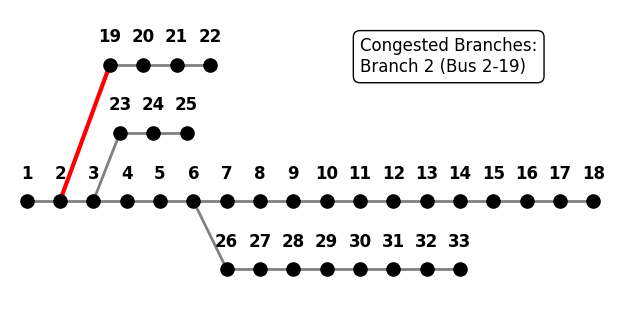

In [46]:
import matplotlib.pyplot as plt
import networkx as nx

# 1. Initialize the Graph
G = nx.Graph()

# 2. Define ALL edges in the IEEE 33-bus system
main_feeder = [(i, i+1) for i in range(1, 18)] # Buses 1 to 18
lateral_1 = [(2, 19), (19, 20), (20, 21), (21, 22)]
lateral_2 = [(3, 23), (23, 24), (24, 25)]
lateral_3 = [(6, 26), (26, 27), (27, 28), (28, 29), (29, 30), (30, 31), (31, 32), (32, 33)]

all_edges = main_feeder + lateral_1 + lateral_2 + lateral_3
G.add_edges_from(all_edges)

# 3. Manually map physical (x, y) coordinates
pos = {}

# Main feeder (Buses 1 to 18) in a straight horizontal line
for i in range(1, 19): 
    pos[i] = (i-0.5, 0)

# Laterals mapped to extremely tight vertical coordinates
for i in range(19, 23): pos[i] = (i - 16, 0.5)   # Lateral 1 (Top high)
for i in range(23, 26): pos[i] = (i - 19.7, 0.25)    # Lateral 2 (Top low)
for i in range(26, 34): pos[i] = (i - 19.5, -0.25)  # Lateral 3 (Bottom)

# 4. Identify Congested Branches
congested_branches = [(2, 19)]
congested_set = set(congested_branches + [(v, u) for u, v in congested_branches])

normal_edges = [edge for edge in G.edges() if edge not in congested_set]
highlighted_edges = [edge for edge in G.edges() if edge in congested_set]

# 5. Build the Plot
plt.figure(figsize=(6, 3))

# Draw Grey Branches (Base Network)
nx.draw_networkx_edges(G, pos, edgelist=normal_edges, edge_color='gray', width=2)

# Draw Red Branches (Congestion)
nx.draw_networkx_edges(G, pos, edgelist=highlighted_edges, edge_color='red', width=3)

# Draw Black Nodes
nx.draw_networkx_nodes(G, pos, node_color='black', node_size=90)

# Offset Node Labels
labels_pos = {k: (v[0], v[1] + 0.1) for k, v in pos.items()}
nx.draw_networkx_labels(G, labels_pos, font_size=12, font_weight='bold')

# 6. Add the Generator Symbol (Node 1)
# plt.plot([0.3, 1], [0, 0], color='gray', linewidth=2, zorder=1) 
# plt.text(0.3, 0, r'$\sim$', fontsize=16, ha='center', va='center', zorder=2,
#          bbox=dict(boxstyle="circle,pad=0.1", fc="white", ec="black", lw=1.2))

# 7. Add the Text Box Legend (MOVED TO THE RED CIRCLED PLACE ABOVE BUS 7-11)
props = dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='black', alpha=1)
plt.text(10.5, 0.6, "Congested Branches:\nBranch 2 (Bus 2-19)", 
         fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=props)

# 8. Lock the Axes Limits to prevent auto-stretching
plt.ylim(-0.4, 0.7)  
plt.xlim(0, 18)      

# 9. Final Formatting and Export
plt.axis('off') 
plt.tight_layout(pad=0)

# Save the plot
plt.savefig("congested_33bus.svg", format="svg", bbox_inches="tight", pad_inches=0.1)

print("Plot successfully generated and saved as congested_33bus.svg")
plt.show()